# Comparision between Xicam and cdsaxs 

The goal of this notebook is to do a comparison between this package cdsaxs and script taken from Xicam for cdsaxs data analysis using real experimental data measured in Brookhaven national laboratory NSLS II synchrotron. In the first part of the notebook we will see the quality of fit compared and the second part will be to compare the execution time between the two.

The First step is to load the expeimental data

In [1]:
from fit import cmaes
import numpy as np
import os
import time
import matplotlib.pyplot as plt

qys = np.load('./data/champs00_p112nm_num2_qxs.npy')
qzs = np.load('./data/champs00_p112nm_num2_qzs.npy')
intensity = np.load('./data/champs00_p112nm_num2_I_peaks.npy')

# FIRST PART

Let's first start with the Xicam. Since Xicam is an entire application which has lots of application other than for CDSAXS we've just imported the relevant part which is in file fit.py obtained from there [github](https://github.com/Xi-CAM/Xi-cam.CDSAXS/blob/master/xicam/CDSAXS/fitting.py).

note: population size(`popsize`) and number of generations(`ngen`) is relatively low or else we need to wait for a long time.

In [2]:
# Define initial parameters and multiples
height = 4.12
swa = [32.66, 88.69, 67.54, 90.0, 81.89, 64.36]
bot_cd = 65.25
dwx = 1.09
dwz = 0.06
i0 = 0.08
bkg = 0.27


multiples = [1E-8, 1E-8, 1E-8, 1E-8, 1E-7, 1E-8] + len(swa) * [1E-8]

initial_guess = np.concatenate([np.array([dwx, dwz, i0, bkg, height, bot_cd]), swa])

# Check if the number of initial guesses matches the number of multiples
assert len(initial_guess) == len(multiples), f'Number of adds ({len(initial_guess)}) is different from number of multiples ({len(multiples)})'

best_corr, best_fitness = cmaes(data=intensity, qxs=qys, qzs=qzs, sigma=10, ngen=10, popsize=100, mu=10,
                                            n_default=len(initial_guess), restarts=0, verbose=False, tolhistfun=10e-5,
                                            initial_guess=initial_guess, ftarget=None, dir_save=None)

print('Best correlation:', best_corr)

Iteration terminated due to ngen criterion after 10 gens
Best correlation: [1.09079904e+00 6.32058507e-02 8.05948281e-02 2.71850459e-01
 4.19497490e+00 6.54706489e+01 3.38824968e+01 8.67518499e+01
 6.64835353e+01 8.92244504e+01 8.13440580e+01 6.58509191e+01]


Now, we perform our simulation in cdsaxs library framework as described in this [tutorial](https://github.com/CEA-MetroCarac/cdsaxs/blob/main/Tutorials/stacked_trapezoid_simulation_and_fitting.ipynb).

In [3]:
from cdsaxs.simulations.stacked_trapezoid import StackedTrapezoidSimulation
from cdsaxs.fitter import Fitter

langles = np.asarray([32.66, 88.69, 67.54, 90.0, 81.89, 64.36])
langles = np.deg2rad(langles)
initial_params = {'heights': {'value': 4.12, 'variation': 1E-8},
                    # 'langles': {'value': langles, 'variation': 1E-8},
                    'rangles': {'value': langles, 'variation': 1E-5},
                    'y_start': {'value': 0, 'variation': 1E-8},
                    'bot_cd': {'value': 65.25, 'variation': 1E-8},
                    'dwx': {'value': 1.09, 'variation': 1E-8},
                    'dwz': {'value': 0.06, 'variation': 1E-8},
                    'i0': {'value': 0.08, 'variation': 1E-8},
                    'bkg_cste': {'value':0.27, 'variation': 1E-7},
                    }


Simulation= StackedTrapezoidSimulation(use_gpu=True, qys=qys, qzs=qzs, initial_guess=initial_params)

Fitter1 = Fitter(Simulation=Simulation, exp_data=intensity)

best_fit, fitness = Fitter1.cmaes(sigma=10, ngen=100, popsize=1000, mu=10, n_default=13, restarts=0, tolhistfun=5E-5, ftarget=0, restart_from_best=True, verbose=False)

/nobackup/nd276333/emcee_env/lib/python3.11/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/nobackup/nd276333/emcee_env/lib/python3.11/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


Iteration terminated due to ngen criterion after 100 gens


/nobackup/nd276333/emcee_env/lib/python3.11/site-packages/cdsaxs/fitter.py:289: RuntimeWarning: invalid value encountered in scalar divide
  if(n_infs / fitness_arr.shape[0] > 0.5):


now let's look at how how close we get to our experimental diffraction data. To do that let's use the structural information we obtained from our fit to obtain simulated diffraction.

In [4]:
params_xicam = {'heights': best_corr[4],
                'y_start': 0.0,
                'bot_cd': best_corr[5],
                'dwx': best_corr[0],
                'dwz': best_corr[1],
                'i0': best_corr[2],
                'bkg_cste': best_corr[3],
                'langles': np.deg2rad(best_corr[6:]),}


params_cdsaxs = {'heights': best_fit['height1'][0],
          'langles': best_fit.filter(like='rangle').values[0],
          'y_start': best_fit['y_start'][0],
          'bot_cd': best_fit['bot_cd'][0],
          'dwx': best_fit['dwx'][0],
          'dwz': best_fit['dwz'][0],
          'i0': best_fit['i0'][0],
          'bkg_cste': best_fit['bkg_cste'][0]}
print(params_xicam)
print(params_cdsaxs)

Simulation2 = StackedTrapezoidSimulation(use_gpu=False, qys=qys, qzs=qzs)

intensity_cdsaxs = Simulation2.simulate_diffraction(params=params_cdsaxs)
intensity_xicam = Simulation2.simulate_diffraction(params=params_xicam)




{'heights': 4.194974901346446, 'y_start': 0.0, 'bot_cd': 65.47064888067975, 'dwx': 1.090799037645903, 'dwz': 0.06320585071787241, 'i0': 0.0805948281349934, 'bkg_cste': 0.2718504593076898, 'langles': array([0.59136113, 1.51410541, 1.16035659, 1.55726043, 1.41972164,
       1.14931535])}
{'heights': 4.119406731109043, 'langles': array([0.58879103, 1.45474463, 1.17316648, 1.61233406, 1.40512862,
       1.16706764]), 'y_start': 0.00013330590227626698, 'bot_cd': 65.24999886343146, 'dwx': 1.088807639021996, 'dwz': 0.06010606794385113, 'i0': 0.08219102165262736, 'bkg_cste': 0.2668247467999129}


Given below is the simple code for separating the 10 orders and plot for this experiment.

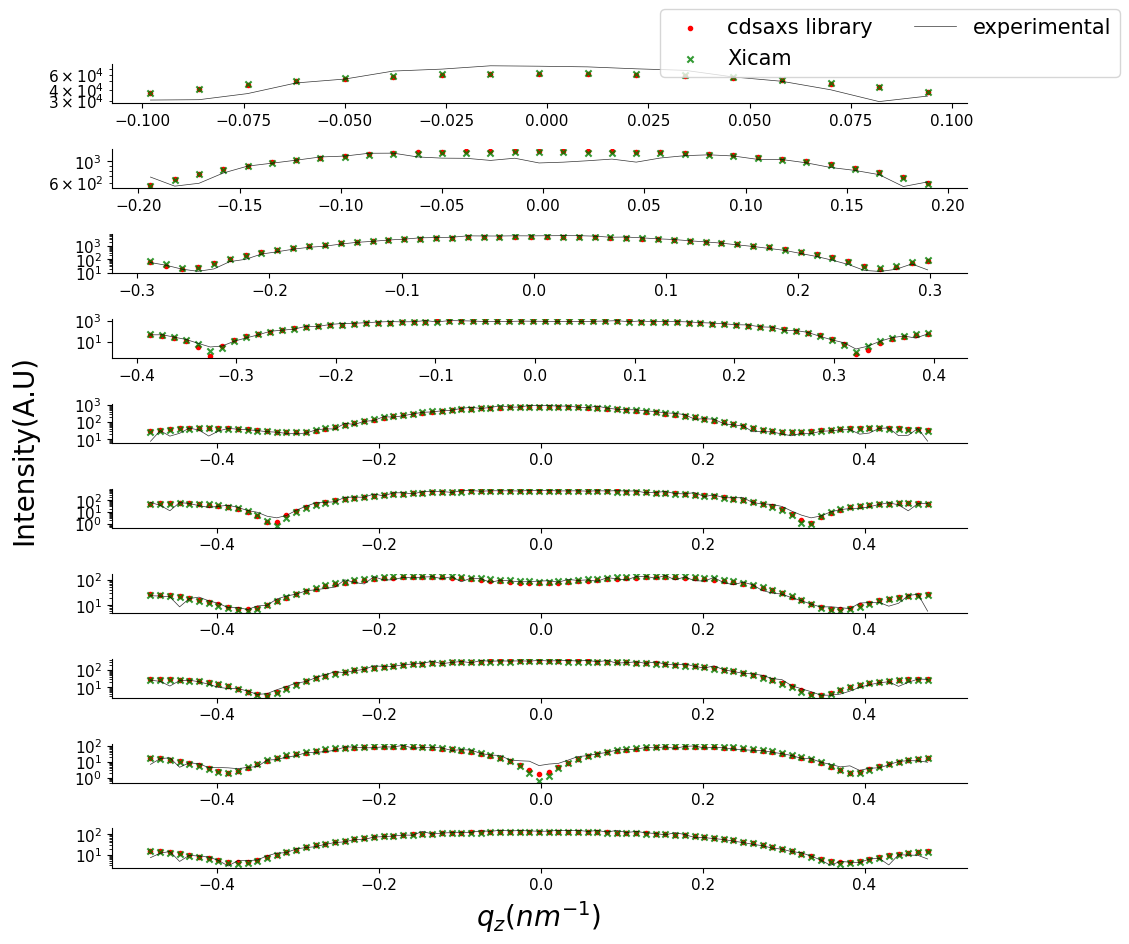

In [16]:

# Find the indices where the sign changes, indicating a new set of measurements
indices_qzs = np.where(np.diff(np.sign(qzs)))[0] + 1
qzs_split = np.split(qzs, indices_qzs)
# Use the above indices to split the intensity and qzs arrays
intensity_cdsaxs_split = np.split(intensity_cdsaxs, indices_qzs)
intensity_xicam_split = np.split(intensity_xicam, indices_qzs)
intensity_split = np.split(intensity, indices_qzs)

# Combine every two consecutive measurements
combined_qzs = [np.concatenate(qzs_split[i:i+2]) for i in range(0, len(qzs_split), 2)]
combined_intensity_cdsaxs = [np.concatenate(intensity_cdsaxs_split[i:i+2]) for i in range(0, len(intensity_cdsaxs_split), 2)]
combined_intensity_xicam = [np.concatenate(intensity_xicam_split[i:i+2]) for i in range(0, len(intensity_xicam_split), 2)]
combined_intensity = [np.concatenate(intensity_split[i:i+2]) for i in range(0, len(intensity_split), 2)]

# Plot each combined measurement in a separate subplot #rouge et blanc noir ligne fine pour experimental
fig, axs = plt.subplots(len(combined_qzs), 1, figsize=(10, 10))
for index in range(len(combined_qzs)):
    axs[index].scatter(combined_qzs[index], combined_intensity_cdsaxs[index], marker='.', color="red", label='cdsaxs library')
    axs[index].scatter(combined_qzs[index], combined_intensity_xicam[index], marker='x', s=20, alpha = 0.8, color="green", label='Xicam')
    axs[index].plot(combined_qzs[index], combined_intensity[index], alpha = 0.8, label='experimental', color="black", linewidth=0.5)

    axs[index].set_yscale('log')
    axs[index].spines['top'].set_visible(False)
    axs[index].spines['right'].set_visible(False)
    # axs[index].spines['bottom'].set_visible(False)
    axs[index].tick_params(axis= 'both', which='both', labelsize=11)
    if index == len(combined_qzs) - 1:
        axs[index].set_xlabel(r'$q_{z}(nm^{-1})$', fontsize=20, fontweight='bold')
        axs[index].spines['bottom'].set_visible(True)
    # else:
    #     axs[i].set_xticks([])

# Global title
# fig.suptitle("Comparison of fit produced by cdsaxs library and Xicam with experimental data", fontsize=20, fontweight='bold')
fig.supylabel("Intensity(A.U)", fontsize=20)

# Extract handles and labels from one of the axes
handles, labels = axs[0].get_legend_handles_labels()

# Global legend
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.9, 0.95), fontsize=15)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

now let's look at the profile in real space:

first we need to write a function to draw the profile from given parameters

In [6]:
def draw_trapezoid_stack(height, angles, bottom_left_x, bottom_right_x):
    """
    Draws a stack of trapezoid shapes and returns the vertices of each trapezoid.

    Parameters:
    height (float): The constant height of each trapezoid layer.
    angles (list of float): A list of angles in degrees, each corresponding to the right and left angles of a layer.
    bottom_left_x (float): The x-coordinate of the bottom-left corner of the first trapezoid.
    bottom_right_x (float): The x-coordinate of the bottom-right corner of the first trapezoid.

    Returns:
    trapezoids (list of tuple): A list of tuples containing vertices of trapezoids.
    """
    trapezoids = []
    current_bottom_left_x = bottom_left_x
    current_bottom_right_x = bottom_right_x
    current_y = 0

    for angle in angles:
        angle_rad = np.radians(angle)
        width_adjust = height / np.tan(angle_rad)  # Horizontal adjustment due to the angle

        # Calculate the next top trapezoid corners
        new_top_left_x = current_bottom_left_x + width_adjust
        new_top_right_x = current_bottom_right_x - width_adjust

        # Store the trapezoid vertices
        xs = [current_bottom_left_x, current_bottom_right_x, new_top_right_x, new_top_left_x, current_bottom_left_x]
        ys = [current_y, current_y, current_y + height, current_y + height, current_y]
        trapezoids.append((xs, ys))

        # Update coordinates for next trapezoid
        current_bottom_left_x = new_top_left_x
        current_bottom_right_x = new_top_right_x

        current_y += height

    return trapezoids


then we can start plotting

Text(0, 0.5, 'Height(nm)')

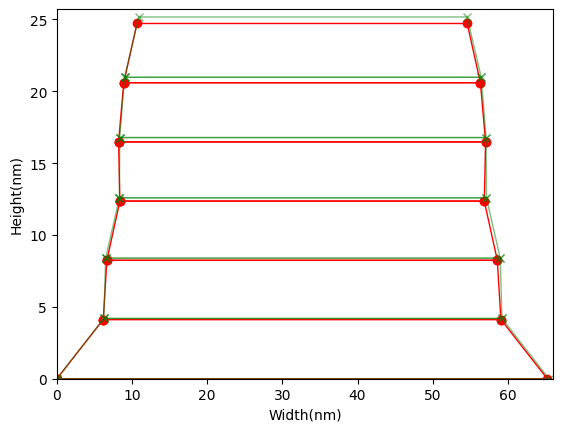

In [7]:

# Bottom trapezoid defined as: (bottom_left_x, bottom_right_x, top_left_x, top_right_x)
angles_cdsaxs = params_cdsaxs['langles'] 
angles_cdsaxs = np.rad2deg(angles_cdsaxs)  # Degrees for each trapezoid layer
height_cdsaxs = params_cdsaxs['heights']  # Constant height of each trapezoid

angles_xicam = params_xicam['langles']
angles_xicam = np.rad2deg(angles_xicam)  
height_xicam = params_xicam['heights']


bottom_left_x_cdsaxs = 0  # x-coordinate of the bottom-left corner of the first trapezoid
bottom_right_x_cdsaxs = params_cdsaxs['bot_cd']  # x-coordinate of the bottom-right corner of the first trapezoid
bottom_left_x_xicam = 0
bottom_right_x_xicam = params_xicam['bot_cd']

trapezoid_vertices_cdsaxs = draw_trapezoid_stack(height_cdsaxs, angles_cdsaxs, bottom_left_x_cdsaxs, bottom_right_x_cdsaxs)
trapezoid_vertices_xicam = draw_trapezoid_stack(height_xicam, angles_xicam, bottom_left_x_xicam, bottom_right_x_xicam)

# Plot the trapezoids
plt.figure()
for xs, ys in trapezoid_vertices_cdsaxs:
    plt.plot(xs, ys, color="red", linewidth=1, marker='o')

for xs, ys in trapezoid_vertices_xicam:
    plt.plot(xs, ys, color="green", linewidth=1, marker='x', alpha = 0.5)

plt.xlim(0, 66)
plt.ylim(0, len(angles_cdsaxs) * height_cdsaxs + 1)
plt.xlabel("Width(nm)")
plt.ylabel("Height(nm)")

# print(params_old)
# print(bestfit)


# SECOND PART

In this part of the notebook we'll try to see the execution time difference between the applications. 


xicam code: Keep in mind that this code is very slow so if you want to run it reduce the number of generation or population

In [8]:
# Define initial parameters and multiples
dwx = 1.09
dwz = 0.06
i0 = 0.08
bkg = 0.27
height = 4.12
bot_cd = 65.25
swa = [32.66, 88.69, 67.54, 90.0, 81.89, 64.36]

initial_guess = np.concatenate([np.array([dwx, dwz, i0, bkg, height, bot_cd]), swa])
multiples = [1E-8, 1E-8, 1E-8, 1E-7, 1E-7, 1E-7] + len(swa) * [1E-6]

# Check if the number of initial guesses matches the number of multiples
assert len(initial_guess) == len(multiples), f'Number of adds ({len(initial_guess)}) is different from number of multiples ({len(multiples)})'

# Define data arrays
data = intensity

time_taken_old = []
pop = [10]#, 50, 100, 500, 1000, 2000]
for i in pop:

    start = time.time()
    best_corr, best_fitness = cmaes(data=data, qxs=qys, qzs=qzs, sigma=10, ngen=100, popsize=i, mu=10,
                                            n_default=len(initial_guess), restarts=0, verbose=False, tolhistfun=5e-5,
                                            initial_guess=initial_guess, ftarget=None, dir_save=None)
    end = time.time()
    time_taken_old.append(end-start)

np.savetxt('time_taken_old.txt', time_taken_old)

Iteration terminated due to ngen criterion after 100 gens


cdsaxs code: both the gpu and cpu execution are tested if you don't have gpu or cupy installed please comment the gpu execution part

In [9]:
langles = np.asarray([32.66, 88.69, 67.54, 90.0, 81.89, 64.36])
langles = np.deg2rad(langles)
initial_params = {'heights': {'value': 4.12, 'variation': 1E-8},
                    # 'langles': {'value': langles, 'variation': 1E-8},
                    'rangles': {'value': langles, 'variation': 1E-5},
                    'y_start': {'value': 0, 'variation': 1E-8},
                    'bot_cd': {'value': 65.25, 'variation': 1E-8},
                    'dwx': {'value': 1.09, 'variation': 1E-8},
                    'dwz': {'value': 0.06, 'variation': 1E-8},
                    'i0': {'value': 0.08, 'variation': 1E-8},
                    'bkg_cste': {'value':0.27, 'variation': 1E-7},
                    }

#GPU execution
Simulation= StackedTrapezoidSimulation(use_gpu=True, qys=qys, qzs=qzs, initial_guess=initial_params)

Fitter1 = Fitter(Simulation=Simulation, exp_data=intensity)

time_taken_gpu = []
pop = [10, 50, 100, 500, 1000, 2000]
for i in pop:
    start = time.time()
    best_fit, fitness = Fitter1.cmaes(sigma=10, ngen=100, popsize=i, mu=10, n_default=13, restarts=0, tolhistfun=5E-5, ftarget=0, restart_from_best=True, verbose=False)
    end = time.time()
    time_taken_gpu.append(end-start)

#CPU execution
Simulation2 = StackedTrapezoidSimulation(use_gpu=False, qys=qys, qzs=qzs, initial_guess=initial_params)

Fitter2 = Fitter(Simulation=Simulation2, exp_data=intensity)
time_taken_cpu = []
pop = [10, 50, 100, 500, 1000, 2000]
for i in pop:
    start = time.time()
    best_fit, fitness = Fitter2.cmaes(sigma=10, ngen=100, popsize=i, mu=10, n_default=13, restarts=0, tolhistfun=5E-5, ftarget=0, restart_from_best=True, verbose=False)
    end = time.time()
    time_taken_cpu.append(end-start)

np.savetxt('time_taken_gpu.txt', time_taken_gpu)
np.savetxt('time_taken_cpu.txt', time_taken_cpu)




Iteration terminated due to ngen criterion after 100 gens


/nobackup/nd276333/emcee_env/lib/python3.11/site-packages/cdsaxs/fitter.py:289: RuntimeWarning: invalid value encountered in scalar divide
  if(n_infs / fitness_arr.shape[0] > 0.5):


Iteration terminated due to ngen criterion after 100 gens


/nobackup/nd276333/emcee_env/lib/python3.11/site-packages/cdsaxs/fitter.py:289: RuntimeWarning: invalid value encountered in scalar divide
  if(n_infs / fitness_arr.shape[0] > 0.5):


Iteration terminated due to ngen criterion after 100 gens


...

Iteration terminated due to ngen criterion after 100 gens


/nobackup/nd276333/emcee_env/lib/python3.11/site-packages/cdsaxs/fitter.py:289: RuntimeWarning: invalid value encountered in scalar divide
  if(n_infs / fitness_arr.shape[0] > 0.5):


Iteration terminated due to ngen criterion after 100 gens


/nobackup/nd276333/emcee_env/lib/python3.11/site-packages/cdsaxs/fitter.py:289: RuntimeWarning: invalid value encountered in scalar divide
  if(n_infs / fitness_arr.shape[0] > 0.5):


KeyboardInterrupt: 

In [ ]:
# plot the time taken for each method

plt.figure()
plt.plot(pop, time_taken_gpu, marker='o', label='cdsaxs GPU')
plt.plot(pop, time_taken_cpu, marker='x', label='cdsaxs CPU')
plt.plot(pop, time_taken_old, marker='s', label='Xicam')
plt.xlabel('Population Size')
plt.ylabel('Time Taken (seconds)')
# plt.title('Time Taken for Different Population Sizes')
plt.legend()
plt.yscale('log')
plt.xlim(0, 2200)
plt.ylim(0, 1E5)
plt.show()